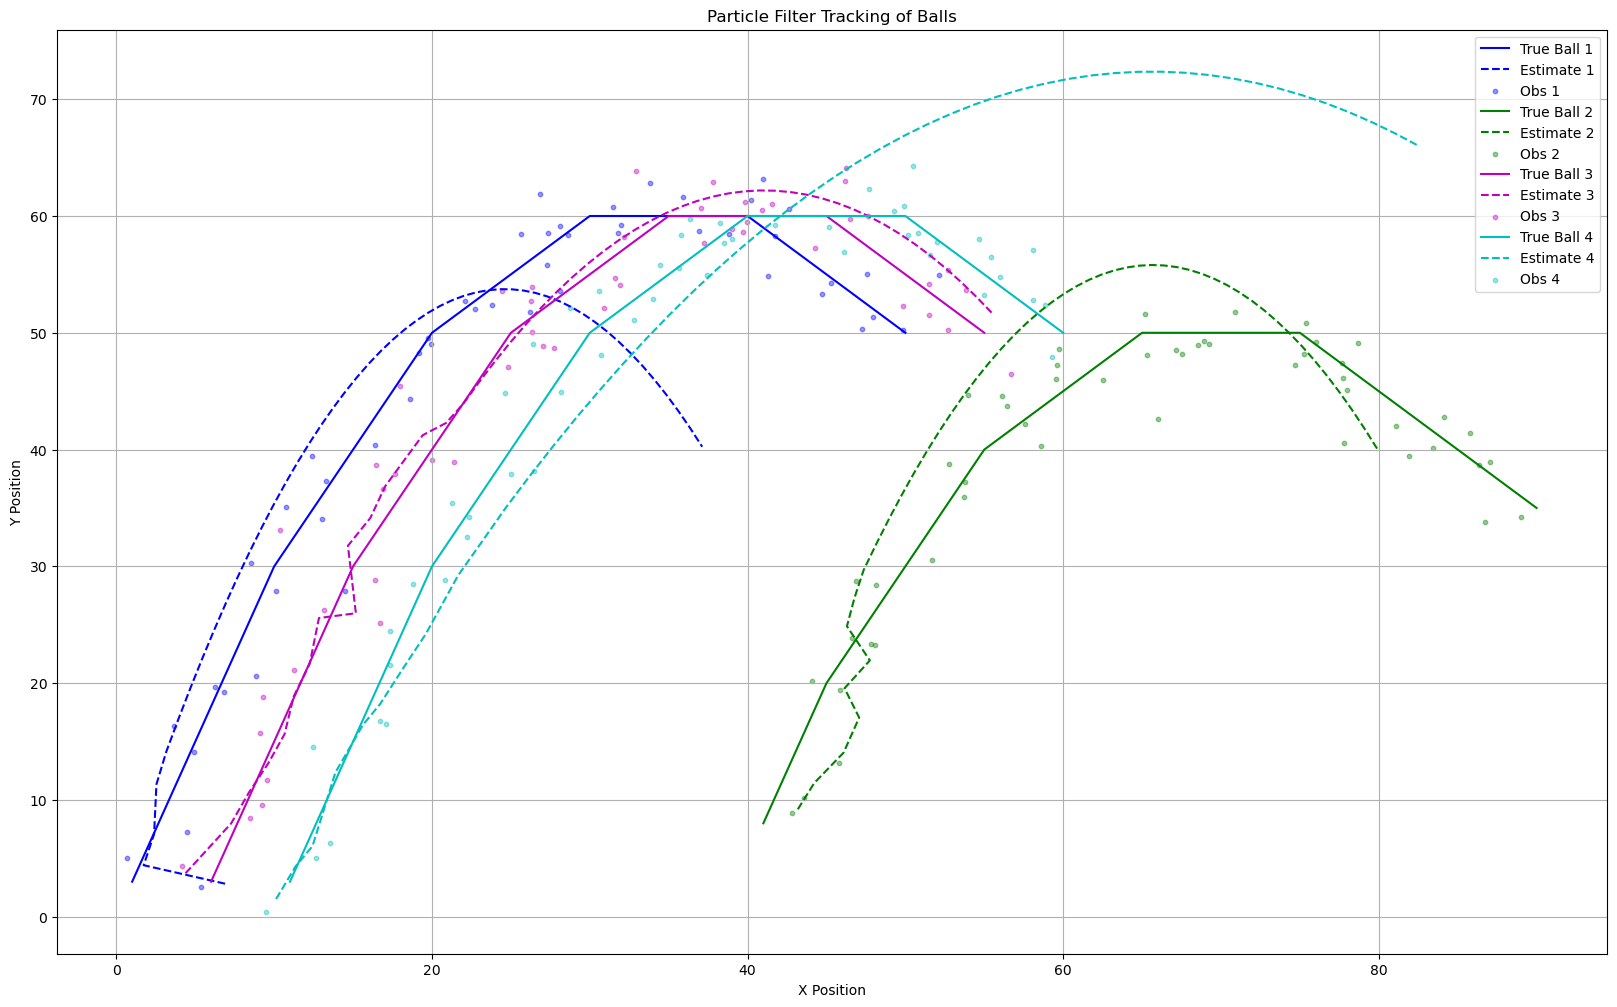

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------- CONFIGURATION --------------------
num_balls = 4  # You can change this

# Define each ball as [x_start, y_start, vx, vy]
initial_conditions = [
    [0, 0, 10, 40],
    [40, 5, 10, 35],
    [5,0,10,40],
    [10,0,10,40]
]
assert len(initial_conditions) == num_balls, "Number of balls must match initial_conditions"
# -------------------------------------------------------

# Constants
g = 9.81
dt = 0.1
steps = 50
N = 500
obs_noise_std = 2.0

# Convert initial conditions into numpy arrays
true_states = [np.array(init) for init in initial_conditions]
true_positions = [[] for _ in range(num_balls)]
observations = [[] for _ in range(num_balls)]
estimates = [[] for _ in range(num_balls)]

# Initialize particle filters
particles = [
    np.random.uniform(low=[-5, -5, 5, 20], high=[55, 55, 15, 40], size=(N, 4))
    for _ in range(num_balls)
]
weights = [np.ones(N) / N for _ in range(num_balls)]

# ----------- Part 1: Simulate Ball Motion -----------
for t in range(steps):
    for i in range(num_balls):
        # Update true state
        true_states[i][0] += true_states[i][2] * dt
        true_states[i][1] += true_states[i][3] * dt - 0.5 * g * dt**2
        true_states[i][3] -= g * dt
        true_positions[i].append(true_states[i][:2].copy())

true_positions = [np.array(tp) for tp in true_positions]

# ----------- Part 2: Generate Noisy Observations -----------
for i in range(num_balls):
    for pos in true_positions[i]:
        noisy = pos + np.random.normal(0, obs_noise_std, size=2)
        observations[i].append(noisy)
observations = [np.array(obs) for obs in observations]

# ----------- Part 3: Particle Filter Tracking -----------
for t in range(steps):
    for i in range(num_balls):
        # Predict
        particles[i][:, 0] += particles[i][:, 2] * dt
        particles[i][:, 1] += particles[i][:, 3] * dt - 0.5 * g * dt**2
        particles[i][:, 3] -= g * dt

        # Update weights
        obs = observations[i][t]
        diff = particles[i][:, :2] - obs
        dists = np.linalg.norm(diff, axis=1)
        w = np.exp(-dists**2 / (2 * obs_noise_std**2))
        w += 1e-300
        w /= np.sum(w)
        weights[i] = w

        # Resample
        indices = np.random.choice(N, N, p=w)
        particles[i] = particles[i][indices]
        weights[i] = np.ones(N) / N

        # Estimate
        est = np.mean(particles[i][:, :2], axis=0)
        estimates[i].append(est)

estimates = [np.array(est) for est in estimates]

# ----------- Part 4: Plotting -----------
colors = ['b', 'g', 'm', 'c', 'y', 'r']
plt.figure(figsize=(20, 12))
for i in range(num_balls):
    color = colors[i % len(colors)]
    plt.plot(true_positions[i][:, 0], true_positions[i][:, 1], color=color, label=f'True Ball {i+1}')
    plt.plot(estimates[i][:, 0], estimates[i][:, 1], '--', color=color, label=f'Estimate {i+1}')
    plt.scatter(observations[i][:, 0], observations[i][:, 1], s=10, alpha=0.4, color=color, label=f'Obs {i+1}')

plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Particle Filter Tracking of Balls")
plt.legend()
plt.grid(True)
plt.show()
